In [543]:
import jax
import jax.numpy as jnp
import numpy as np
from tqdm import tqdm
import random

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

import optax

In [544]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X - 128
X = X / 128
X.min(), X.max()

(np.float64(-1.0), np.float64(0.9921875))

In [664]:
def encoder(params, X):
    Xnoisy = X + np.random.randn(*X.shape)*0.3
    for p in params:
        Xnoisy = Xnoisy @ p
        Xnoisy = jax.nn.selu(Xnoisy)
    return Xnoisy

def decoder(params, X):
    for i,p in enumerate(params):
        X = X @ p
        if i != len(params)-1:
            X = jax.nn.selu(X)
        else:
            X = jax.nn.tanh(X)
    return X

In [665]:
def model(params,X):
    epars, dpars = params
    e =  encoder(epars, X) 
    return decoder(dpars, e)

@jax.jit
@jax.value_and_grad
def lossfn(params, X):
    Xhat = model(params, X)
    return jnp.sum((Xhat - X)**2)/X.shape[0]/X.shape[1]

In [675]:
encshape = [784,128,64,16,2]
decshape = list(reversed(encshape))

encparams = [np.random.randn(encshape[i],encshape[i+1])*0.1 for i in range(len(encshape)-1)]
decparams = [np.random.randn(decshape[i],decshape[i+1])*0.1 for i in range(len(decshape)-1)]
# lossfn(params, X)
params = [encparams, decparams]

for p in encparams:
    print(p.shape)
for p in decparams:
    print(p.shape)

(784, 128)
(128, 64)
(64, 16)
(16, 2)
(2, 16)
(16, 64)
(64, 128)
(128, 784)


In [685]:

optimizer = optax.adamw(learning_rate=1e-3)
state = optimizer.init(params)

EPOCHS = 200
pbar = tqdm(range(EPOCHS), ncols=80, colour='blue', position=0)

for i in pbar:
    loss, grads = lossfn(params, X)
    pbar.set_postfix_str(f"loss:{float(loss):.3f}")
    updates, state = optimizer.update(grads, state, params)
    params = optax.apply_updates(params, updates)

    

100%|█████████████████████████████| 200/200 [00:14<00:00, 13.38it/s, loss:0.223]


<Axes: >

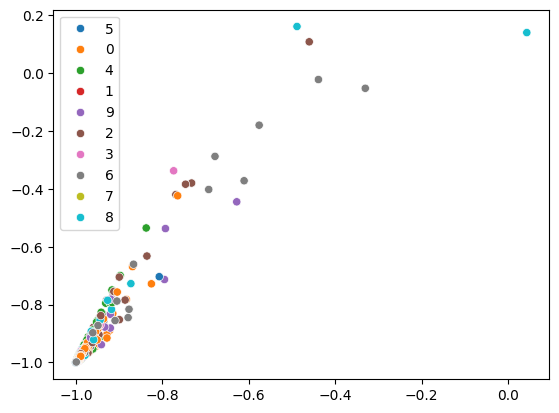

In [686]:
latent = model(params, X)

sns.scatterplot(x=latent[:,0], y=latent[:,1], hue=y)

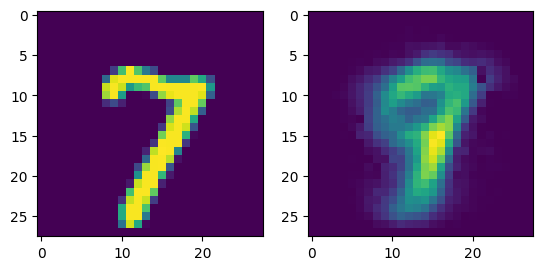

In [693]:
idx = random.randint(0,1000)
plt.subplot(1,2,1)
plt.imshow(X[idx].reshape(28,28))
plt.subplot(1,2,2)
plt.imshow(model(params, X[idx]).reshape(28,28))